# Predicting Air Turbulence Using Machine Learning
By: Chee Qian Wen
<br>Feb 25

## Part 4 of 5: Exploratory Data Analyses (EDA)
In Part 3, the focus was on engineering new features and creating dummy variables (one-hot encoding) for categorical variables. Please refer to Part 2 to see how the following data were created:
1) 'cleaned_data.csv'

Part 4 involves exploratory data analyses (EDA). EDA is a crucial step in the machine learning pipeline that involves analyzing and visualizing the data to patterns, trends, and relationships before building models. It helps in identifying the best features to build the machine learning model.

### 4.1. Import Libraries
First, the necessary libraries required are imported.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import plotly.graph_objects as go
import requests

In [4]:
df = pd.read_csv('cleaned_data.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)

### 4.2. Plotting Charts
The next step involves plotting several charts for the key features in the dataset to identify patterns and trends.

#### 4.2.1. Number of Reports Over Time
It is clear that the number of turbulence reports have increased over the past 10 years, reflecting a trend that incidents of turbulence have been on the rise due to climate change.

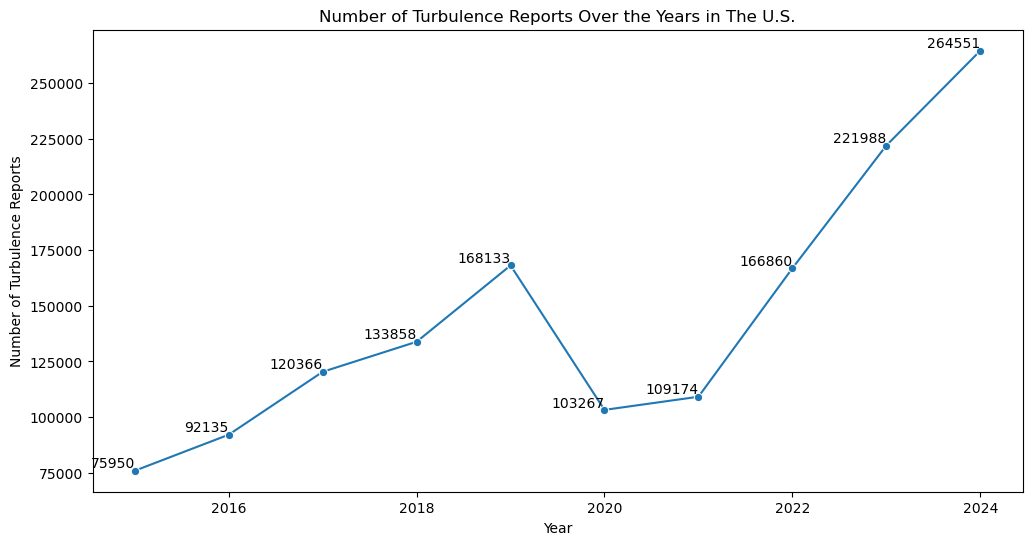

In [7]:
# Group by year and count reports
yearly_counts = df['YEAR'].value_counts().sort_index()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o')

# Add labels to each point
for x, y in zip(yearly_counts.index, yearly_counts.values):
    plt.text(x, y, str(y), fontsize=10, ha='right', va='bottom', color='black')

# Labels and title
plt.xlabel("Year")
plt.ylabel("Number of Turbulence Reports")
plt.title("Number of Turbulence Reports Over the Years in The U.S.")
plt.show()

By plotting a separate line graph for each category, we can see that the increase in turbulence over the years is mainly driven by an increase in light and moderate turbulence reports. Number of severe and extreme turbulence reports have remained stable over the years.

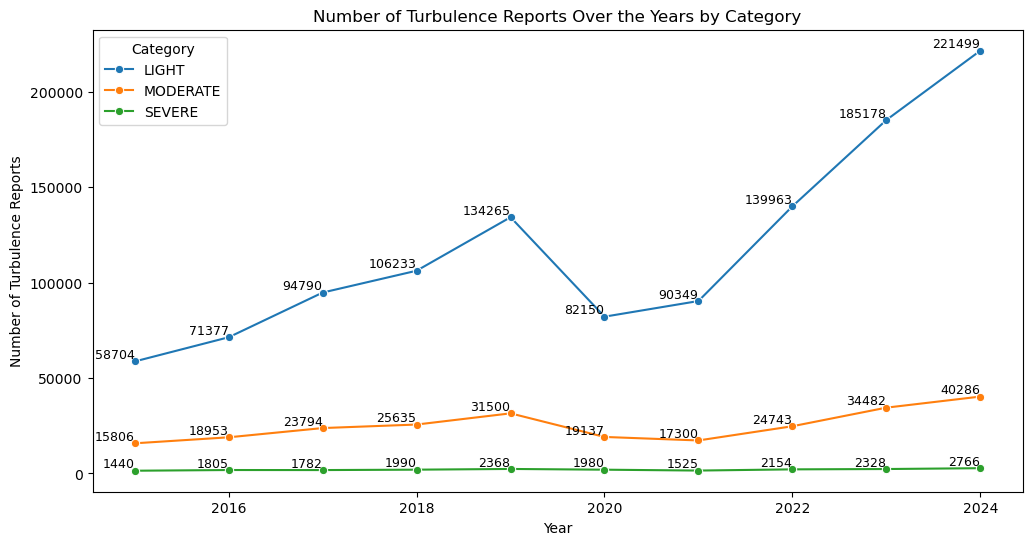

In [11]:
yearly_turb_counts = df.groupby(['YEAR', 'TURB']).size().reset_index(name='count')

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_turb_counts, x='YEAR', y='count', hue='TURB', marker='o')

# Add labels to each point
for _, row in yearly_turb_counts.iterrows():
    plt.text(row['YEAR'], row['count'], str(row['count']), fontsize=9, ha='right', va='bottom', color='black')

# Labels and title
plt.xlabel("Year")
plt.ylabel("Number of Turbulence Reports")
plt.title("Number of Turbulence Reports Over the Years by Category")
plt.legend(title="Category")
plt.show()

#### 4.2.2. Severity of Turbulence by Urgency
Urgency of report is a very strong indication of the severity of turbulence. Typically, when pilots indicate that a report is "urgent", the severity of turbulence tends to be a lot higher.

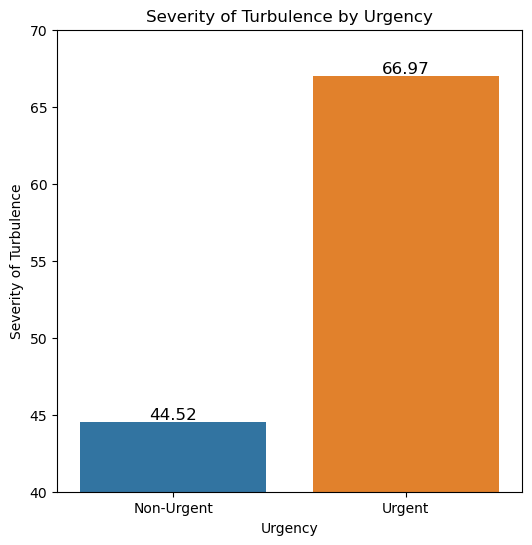

In [11]:
# Group by URGENT and calculate mean TURB_DEG
urgency_turbulence = df.groupby("URGENT")["TURB_DEG"].mean().reset_index()

# Convert URGENT to string labels
urgency_turbulence["URGENT"] = urgency_turbulence["URGENT"].map({True: "Urgent", False: "Non-Urgent"})

# Sort order
urgency_order = ["Non-Urgent", "Urgent"]

# Plot
plt.figure(figsize=(6,6))
ax = sns.barplot(data=urgency_turbulence, x="URGENT", y="TURB_DEG", order=urgency_order, hue = "URGENT")

# Add values on top of bars
for bar in ax.patches:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{bar.get_height():.2f}", 
             ha="center", va="bottom", fontsize=12)
    
# Labels and title
plt.xlabel("Urgency")
plt.ylabel("Severity of Turbulence")
plt.title("Severity of Turbulence by Urgency")
plt.ylim(40, 70)  # Adjust as needed
plt.show()

#### 4.2.3. Severity of Turbulence by Month
There appears to be a trend in the severity of turbulence by month. Specifically, turbulence appears to be the weakest in the Summer months (Jun-Aug) and the worst in the Winter months (Dec - Mar).

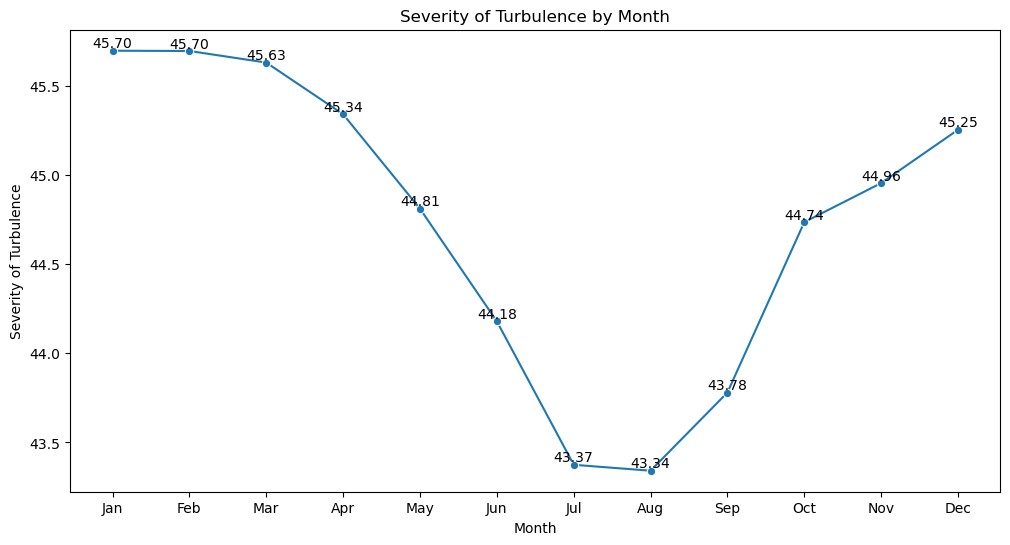

In [13]:
monthly_turbulence = df.groupby("MONTH")["TURB_DEG"].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=monthly_turbulence, x="MONTH", y="TURB_DEG", marker="o")

# Add labels to data points
for i, row in monthly_turbulence.iterrows():
    plt.text(row["MONTH"], row["TURB_DEG"], f'{row["TURB_DEG"]:.2f}', 
             ha='center', va='bottom', fontsize=10, color='black')

# Set x-axis labels
plt.xticks(ticks=range(1, 13), labels=[
    "Jan", "Feb", "Mar", "Apr", "May", "Jun", 
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
])

# Labels and title
plt.xlabel("Month")
plt.ylabel("Severity of Turbulence")
plt.title("Severity of Turbulence by Month")
plt.show()

We can observe this by comparing the average turbulence severity for each season. Again, turbulence is weakest in Summer and worst in Winter. Turbulence can often be worse in winter because of the significant temperature contrast between land and ocean, which creates stronger jet streams with more pronounced wind shear, leading to increased occurrences of clear-air turbulence, where bumpy conditions can occur even when the sky appears clear; essentially, the larger temperature difference between air masses in winter results in more unstable air conditions for flights. 

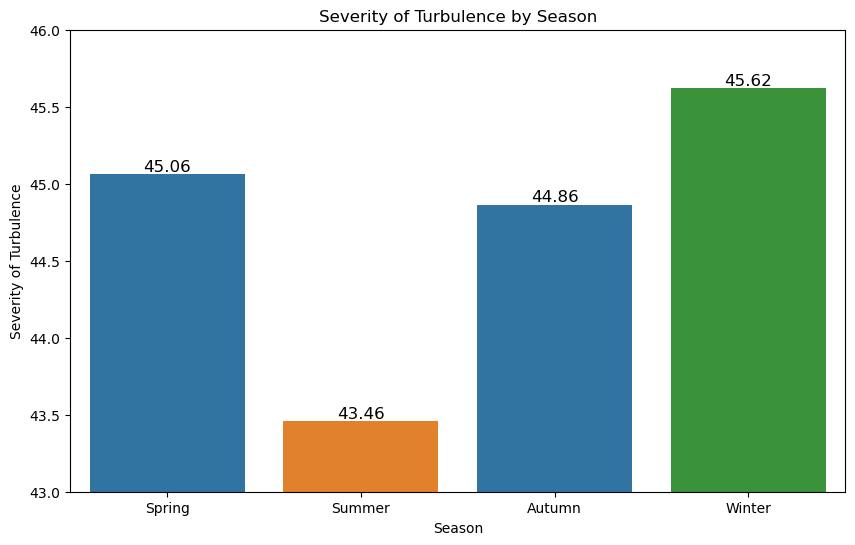

In [15]:
season_turbulence = df.groupby("SEASON")["TURB_DEG"].mean().reset_index()

# Define custom colors
custom_colors = {
    "Spring": "#1f77b4", 
    "Summer": "#ff7f0e",
    "Autumn": "#1f77b4",
    "Winter": "#2ca02c"
}

# Set order for bars
season_order = ["Spring", "Summer", "Autumn", "Winter"]

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=season_turbulence, x="SEASON", y="TURB_DEG",
    order=season_order, hue="SEASON", palette=custom_colors, legend=False
)

# Add values on top of bars
for bar in ax.patches:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{bar.get_height():.2f}", 
             ha="center", va="bottom", fontsize=12)
    
# Labels and title
plt.xlabel("Season")
plt.ylabel("Severity of Turbulence")
plt.title("Severity of Turbulence by Season")
plt.ylim(43, 46)
plt.show()

#### 4.2.4. Severity of Turbulence by Hour
There also appears to be a trend in the severity of turbulence by hour. Specifically, turbulence appears to increase throughout the day, before decreasing through the night, with the calmest turbulence during early morning hours.

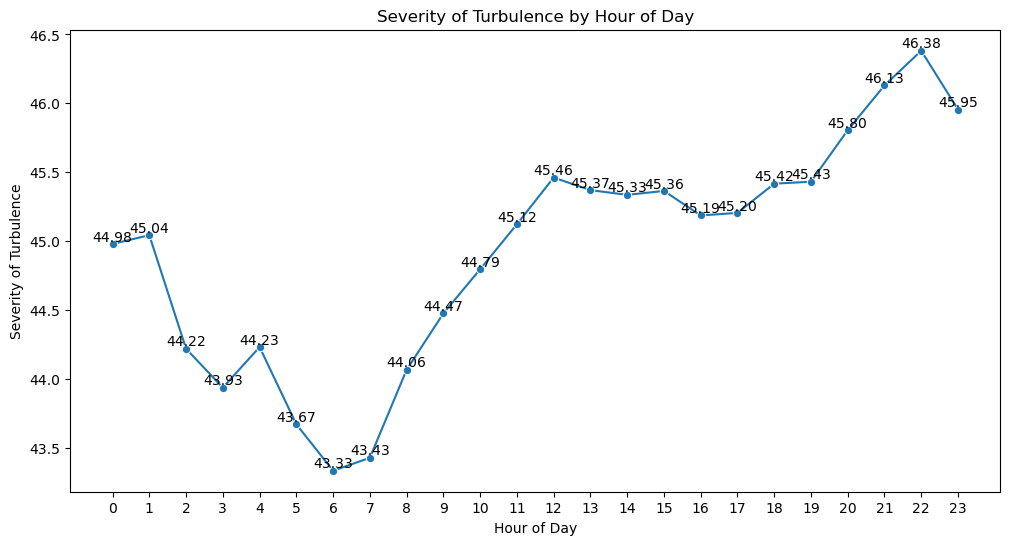

In [17]:
hourly_turbulence = df.groupby("HOUR")["TURB_DEG"].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=hourly_turbulence, x="HOUR", y="TURB_DEG", marker="o")

# Add labels to data points
for i, row in hourly_turbulence.iterrows():
    plt.text(row["HOUR"], row["TURB_DEG"], f'{row["TURB_DEG"]:.2f}', 
             ha='center', va='bottom', fontsize=10, color='black')
    
plt.xticks(ticks=range(24), labels=[str(i) for i in range(24)])

# Labels and title
plt.xlabel("Hour of Day")
plt.ylabel("Severity of Turbulence")
plt.title("Severity of Turbulence by Hour of Day")
plt.show()

We can observe this by comparing the average turbulence severity by time of day. Again, turbulence is calmest in during early morning hours. Turbulence is typically least during early morning hours because the atmosphere is generally calmer with less convective activity, meaning fewer rising air currents, due to the reduced sunlight and cooler temperatures, resulting in slower wind speeds and less potential for turbulent conditions compared to the warmer daytime hours. 

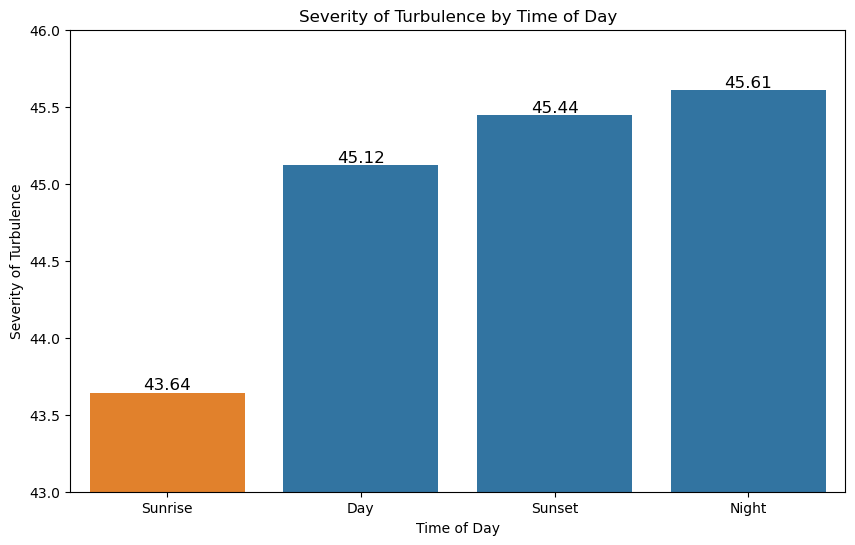

In [19]:
time_turbulence = df.groupby("TIME_OF_DAY")["TURB_DEG"].mean().reset_index()

# Define custom colors
custom_colors = {
    "Sunrise": "#ff7f0e",
    "Day": "#1f77b4",
    "Sunset": "#1f77b4",
    "Night": "#1f77b4"
}

# Set order for bars
time_order = ["Sunrise", "Day", "Sunset", "Night"]

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=time_turbulence, x="TIME_OF_DAY", y="TURB_DEG",
    order=time_order, hue="TIME_OF_DAY", palette=custom_colors, legend=False
)

# Add values on top of bars
for bar in ax.patches:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{bar.get_height():.2f}", 
             ha="center", va="bottom", fontsize=12)
    
# Labels and title
plt.xlabel("Time of Day")
plt.ylabel("Severity of Turbulence")
plt.title("Severity of Turbulence by Time of Day")
plt.ylim(43, 46)
plt.show()

#### 4.2.5. Severity of Turbulence by Weight Class
It is also clear that the severity of turbulence differs by weight class. Lighter jets experience more turbulence because they have less mass, making them more susceptible to being moved around by air pockets and turbulent air currents. On the other hand, the larger mass of a heavier aircraft acts as a stabilizing force against turbulence. 

However, based on our dataset, super jets (such as the double-decker A380-800) experience the strongest turbulence. This might be because these jets tend to fly at higher altitudes, and are more susceptible to clear-air turbulence.

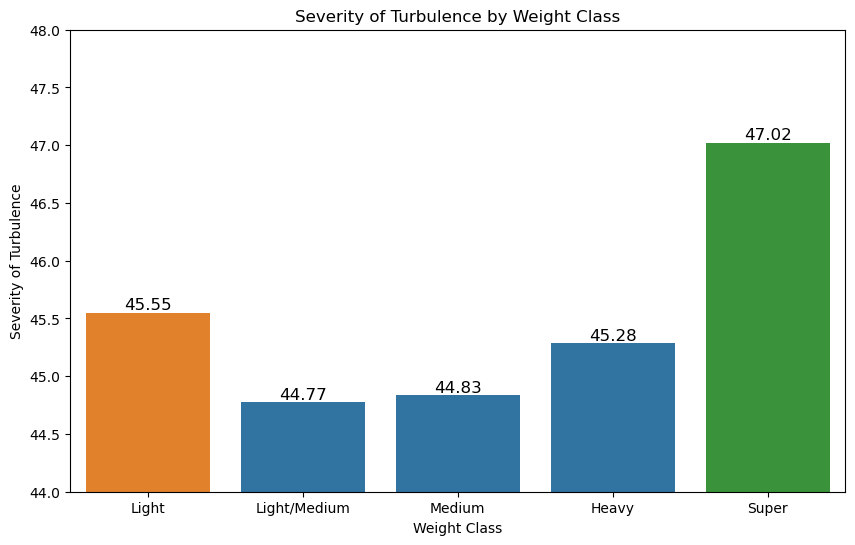

In [21]:
wtc_turbulence = df.groupby("WTC")["TURB_DEG"].mean().reset_index()

# Set order for bars
wtc_order = ["L", "L/M", "M", "H","J"]
custom_labels = ["Light", "Light/Medium", "Medium", "Heavy", "Super"]  

# Define custom colors
custom_colors = {
    "L": "#ff7f0e",
    "L/M": "#1f77b4",
    "M": "#1f77b4",
    "H": "#1f77b4",
    "J": "#2ca02c"
}

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=wtc_turbulence, x="WTC", y="TURB_DEG",
    order=wtc_order, hue="WTC", palette=custom_colors, legend=False
)

# Add values on top of bars
for bar in ax.patches:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{bar.get_height():.2f}", 
             ha="center", va="bottom", fontsize=12)
    
# Labels and title
plt.xticks(ticks=range(len(wtc_order)), labels=custom_labels)
plt.xlabel("Weight Class")
plt.ylabel("Severity of Turbulence")
plt.title("Severity of Turbulence by Weight Class")
plt.ylim(44, 48)
plt.show()

#### 4.2.6. Severity of Turbulence by Flight Level (Altitude)
Maximum turbulence usually occurs near the mid-level of the storm, between 12,000 and 20,000 feet, due to clouds of the greatest vertical development. Turbulence is also worst at highest altitudes due to clear-air turbulence. Turbulence is calmest at out-of-cloud cruising altitudes of between 30,000 to 40,000 ft.

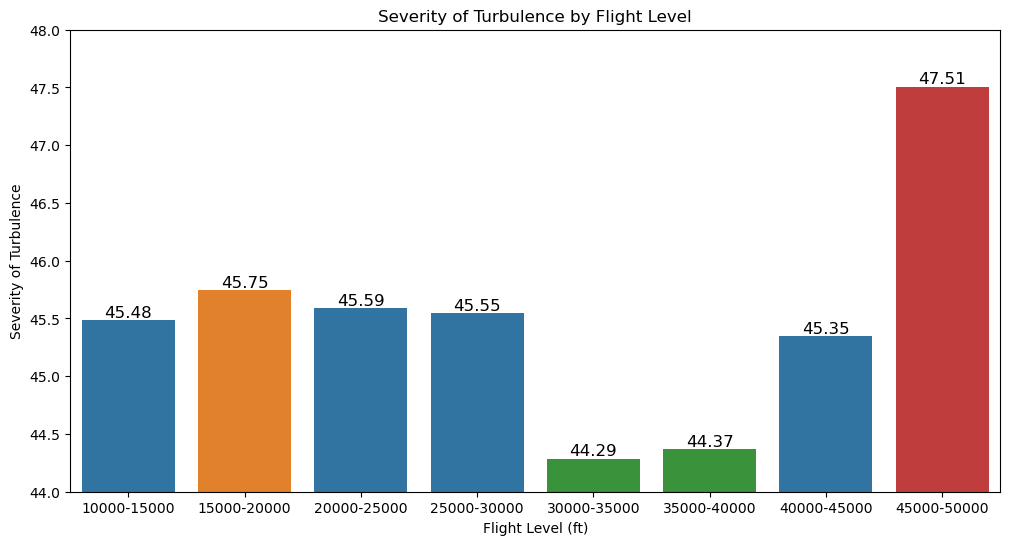

In [23]:
# Define bins and labels
bins = np.arange(10000, 55000, 5000)  # Bins from 10,000 to 50,000 in 5,000 ft intervals
labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins) - 1)]  # Create bin labels

# Assign FL values to bins
df["FL_BIN"] = pd.cut(df["FL"], bins=bins, labels=labels, right=False)

# Group by FL_BIN and calculate mean turbulence severity
fl_turbulence = df.groupby("FL_BIN", observed=False)["TURB_DEG"].mean().reset_index()

# Define specific colors for each bin (adjust as needed)
custom_colors = [
    "#1f77b4", "#ff7f0e", "#1f77b4", "#1f77b4", "#2ca02c",
    "#2ca02c", "#1f77b4", "#d62728", "#F08080"
][:len(fl_turbulence)]  # Ensure the color list matches the number of bins

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=fl_turbulence, x="FL_BIN", y="TURB_DEG", hue="FL_BIN", palette=custom_colors)

# Add values on top of bars
for bar in ax.patches:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{bar.get_height():.2f}", 
             ha="center", va="bottom", fontsize=12)
    
# Labels and title
plt.xlabel("Flight Level (ft)")
plt.ylabel("Severity of Turbulence")
plt.title("Severity of Turbulence by Flight Level")
plt.ylim(44, 48)
plt.show()

#### 4.2.7. Severity of Turbulence by Distance to Ground
Turbulence is often worse closer to the ground because of the interaction between air and the uneven terrain, creating air pockets and eddies due to friction with the surface, especially when combined with strong winds or unstable air conditions, which are more pronounced near the ground; this phenomenon is called "mechanical turbulence". 

Away from the ground, severity of turbulence decreases until it reaches high altitudes, where the risk of clear air turbulence increases.

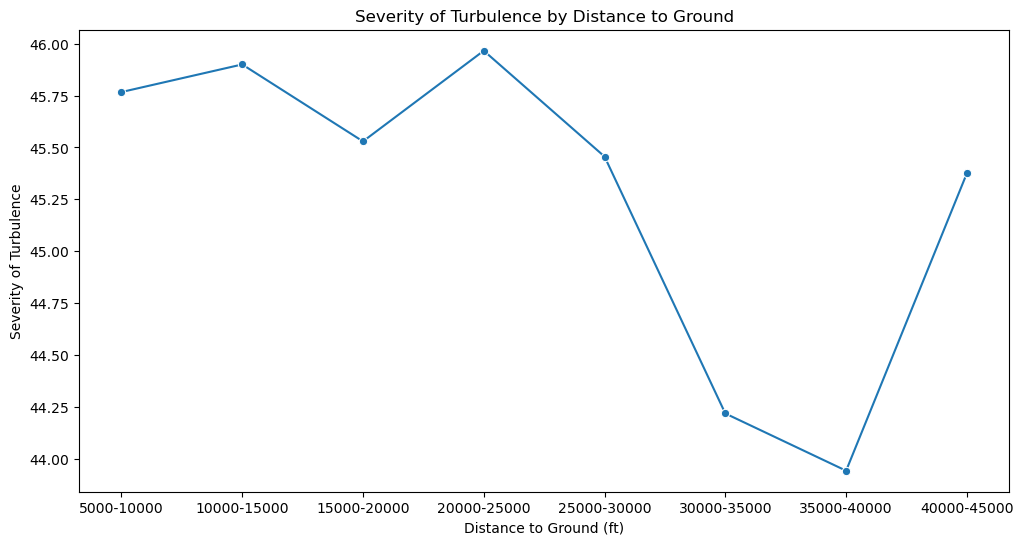

In [25]:
# Define 10 equal-width bins for distance to ground
ground_bins = np.linspace(5000, 45000, num=9)  # 10 bins = 11 edges
ground_labels = [f"{int(ground_bins[i])}-{int(ground_bins[i+1])}" for i in range(len(ground_bins) - 1)]  # Bin labels

# Assign DISTANCE_TO_GROUND values to bins
df["GROUND_BIN"] = pd.cut(df["DISTANCE_TO_GROUND"], bins=ground_bins, labels=ground_labels, right=False)

# Group by binned distance and calculate average turbulence severity
binned_turbulence = df.groupby("GROUND_BIN", observed=False)["TURB_DEG"].mean().reset_index()

# Convert bins to string for correct ordering
binned_turbulence["GROUND_BIN"] = binned_turbulence["GROUND_BIN"].astype(str)

# Plot line chart
plt.figure(figsize=(12, 6))
sns.lineplot(data=binned_turbulence, x="GROUND_BIN", y="TURB_DEG", marker="o")

# Labels and title
plt.xlabel("Distance to Ground (ft)")
plt.ylabel("Severity of Turbulence")
plt.title("Severity of Turbulence by Distance to Ground")
plt.show()

#### 4.2.8. Severity of Turbulence by Wind Direction
In the U.S., the prevailing winds are primarily Westerlies, which blow from the West to the East. They are responsible for moving weather systems, including storms and jet streams.

Turbulence is the calmest when the wind direction at the location is in alignment with prevailing winds (i.e., from West to East). 

Turbulence is worst when the wind direction at the location is against the prevailing wind (i.e., from East to West).

Turbulence is also worst when the wind direction at the location is a crosswind, i.e., perpendicular to the direction of travel, rather than directly head-on or from behind (i.e., from North to South, or South to North).

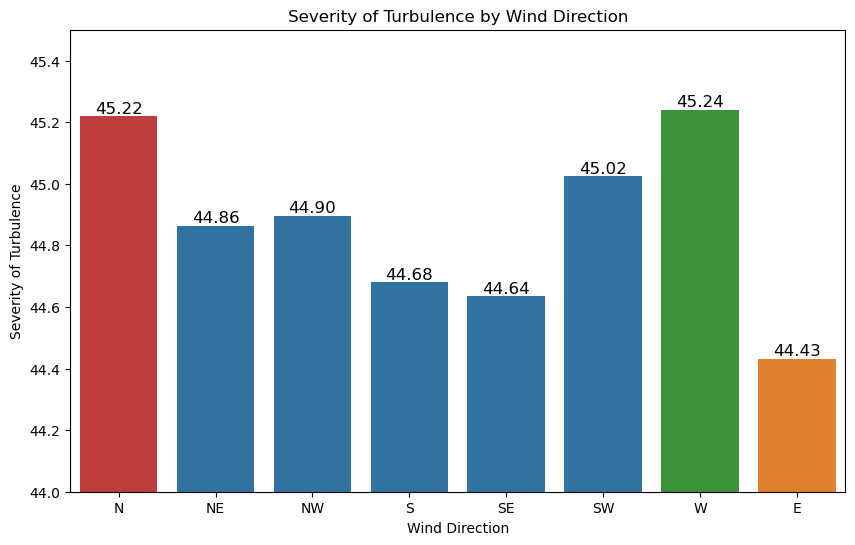

In [27]:
wind_turbulence = df.groupby("WIND_DIR")["TURB_DEG"].mean().reset_index()

# Set order for bars
wind_order = ["N", "NE", "NW", "S","SE","SW","W","E"]

# Define custom colors
custom_colors = {
    "E": "#ff7f0e",
    "W": "#2ca02c",
    "N": "#d62728",
    "NE": "#1f77b4",
    "NW": "#1f77b4",
    "S": "#1f77b4",
    "SE": "#1f77b4",
    "SW": "#1f77b4",
}

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=wind_turbulence, x="WIND_DIR", y="TURB_DEG",
    order=wind_order, hue = "WIND_DIR", palette = custom_colors, legend=False
)

# Add values on top of bars
for bar in ax.patches:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{bar.get_height():.2f}", 
             ha="center", va="bottom", fontsize=12)
    
# Labels and title
plt.xlabel("Wind Direction")
plt.ylabel("Severity of Turbulence")
plt.title("Severity of Turbulence by Wind Direction")
plt.ylim(44, 45.5)
plt.show()

#### 4.2.9. Severity of Turbulence by Location
Location is a key feature when predicting turbulence in the U.S. In general, there are 3 key hotspots for turbulence:
1) The Mountains: The most turbulent area is the one of the mountains. The main reason is that the air is forced up and down as it passes through them, and this generates a wide range of turbulent structures that can shake the plane. This turbulence can propagate far from the mountains, sometimes in the form of rolling trains of vortices known as mountain waves. At cruising altitudes the wind in the US is from west to east. Therefore most of the turbulence should be located at the eastern side of the mountains. For example, the turbulent patch near Mt Elbert is on the east of the mountain.

2) The Great Plains: This area presents the lowest levels of turbulence in the US. The flat terrain is an important factor. But also, the plains are sheltered from the Pacific and Atlantic winds by the Rockies and Appalachians. These two factors bring a peaceful patch of air with very low turbulence levels.

3) Texas and Mississippi: The turbulence levels in these areas are also large. For Texas, it seems that the turbulence from the Sierra Madre is propagating eastwards. For Mississippi, a flat river valley is not expected to be an important generator of turbulence. But somehow pilots report larger levels here, and there is no sound explanation for it.

In [29]:
# Define grid size (7.5° x 7.5°)
lat_bins = np.arange(20, 56, 0.75)  # Latitude range for the US
lon_bins = np.arange(-130, -59, 0.75)  # Longitude range for the US

# Create bin labels
lat_labels = [f"{lat_bins[i]}-{lat_bins[i+1]}" for i in range(len(lat_bins) - 1)]
lon_labels = [f"{lon_bins[i]}-{lon_bins[i+1]}" for i in range(len(lon_bins) - 1)]

# Assign bins
df["LAT_BIN"] = pd.cut(df["LAT"], bins=lat_bins, labels=lat_labels, right=False)
df["LON_BIN"] = pd.cut(df["LON"], bins=lon_bins, labels=lon_labels, right=False)

# Convert bins to string and remove NaN issues
df.dropna(subset=["LAT_BIN", "LON_BIN"], inplace=True)

In [30]:
# Assign numeric bins (no labels)
df["LAT_BIN"] = pd.cut(df["LAT"], bins=lat_bins, right=False)
df["LON_BIN"] = pd.cut(df["LON"], bins=lon_bins, right=False)

# Compute bin centers correctly
df["LAT_CENTER"] = df["LAT_BIN"].apply(lambda x: x.mid if pd.notna(x) else np.nan)
df["LON_CENTER"] = df["LON_BIN"].apply(lambda x: x.mid if pd.notna(x) else np.nan)

# Drop NaNs safely
df.dropna(subset=["LAT_CENTER", "LON_CENTER"], inplace=True)

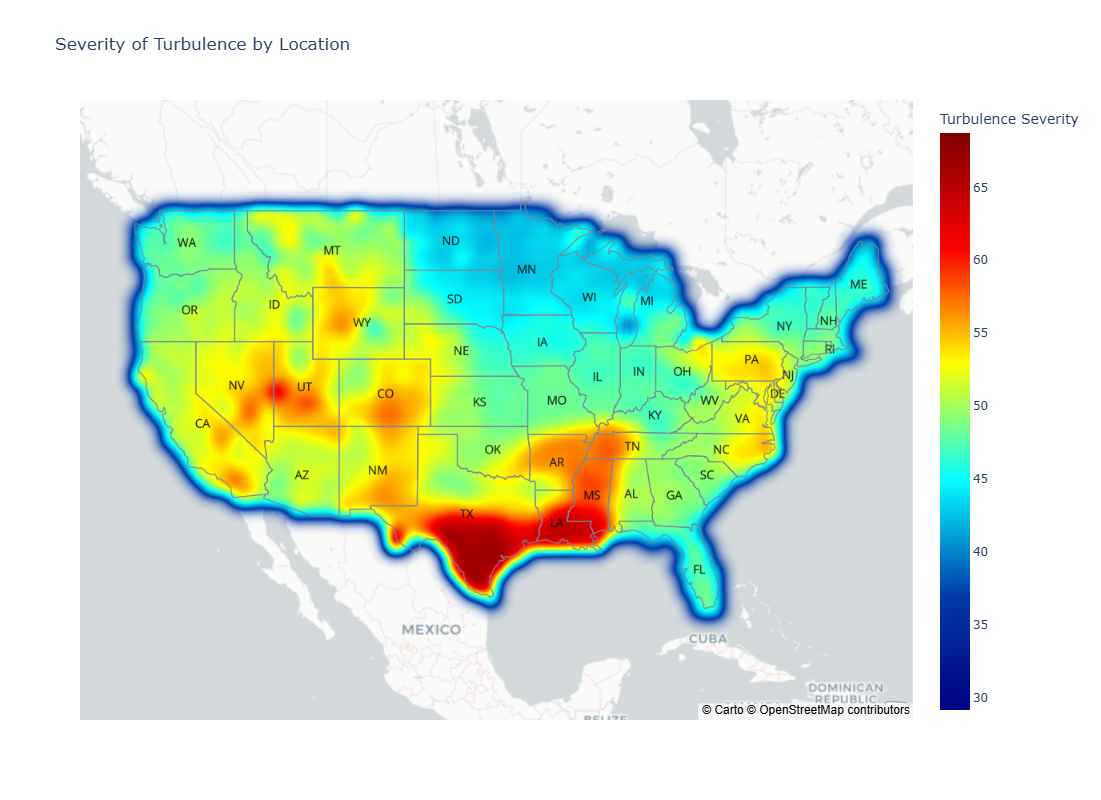

In [59]:
# Group by lat/lon grid squares and compute avg turbulence
heatmap_data = df.groupby(["LAT_CENTER", "LON_CENTER"], observed=False)["TURB_DEG"].mean().reset_index()

# Create heatmap
fig = px.density_mapbox(
    heatmap_data,
    lat="LAT_CENTER",
    lon="LON_CENTER",
    z="TURB_DEG",
    radius=24,
    color_continuous_scale="Jet",
    title="Severity of Turbulence by Location",
    mapbox_style="carto-positron",
    center={"lat": 38, "lon": -97},
    zoom=3.2,
    hover_data={
        "LAT_CENTER": True,
        "LON_CENTER": True,
        "TURB_DEG": True
    },
    labels={
        "LAT_CENTER": "Latitude",
        "LON_CENTER": "Longitude",
        "TURB_DEG": "Average Turbulence"
    }
)

# Approximate state center coordinates (for labeling)
state_centers = {
    "CA": (-119.5, 37.2), "TX": (-99.3, 31.5), "FL": (-81.5, 27.8), 
    "NY": (-75.0, 42.9), "IL": (-89.3, 40.0), "PA": (-77.5, 41.0),
    "OH": (-82.8, 40.3), "GA": (-83.4, 32.7), "NC": (-79.8, 35.6),
    "MI": (-85.5, 44.3), "NJ": (-74.7, 40.1), "VA": (-78.2, 37.5),
    "WA": (-120.7, 47.4), "AZ": (-111.9, 34.0), "MA": (-71.8, 42.3),
    "TN": (-86.6, 35.8), "IN": (-86.1, 40.3), "MO": (-92.4, 38.6),
    "MD": (-76.8, 39.1), "WI": (-89.9, 44.5), "CO": (-105.5, 39.0),
    "MN": (-94.7, 46.0), "SC": (-80.9, 34.0), "AL": (-86.7, 32.8),
    "LA": (-92.4, 30.9), "KY": (-84.9, 37.7), "OR": (-120.5, 43.8),
    "OK": (-97.3, 35.6), "CT": (-72.7, 41.6), "IA": (-93.5, 42.0),
    "MS": (-89.7, 32.7), "AR": (-92.4, 34.8), "UT": (-111.7, 39.4),
    "NV": (-116.9, 39.5), "KS": (-98.3, 38.5), "NM": (-106.1, 34.3),
    "NE": (-99.7, 41.5), "WV": (-80.7, 38.6), "ID": (-114.0, 44.1),
    "HI": (-157.5, 20.9), "ME": (-69.3, 45.2), "NH": (-71.6, 43.2),
    "MT": (-109.6, 47.0), "RI": (-71.5, 41.6), "DE": (-75.5, 39.0),
    "SD": (-100.2, 44.4), "ND": (-100.5, 47.5), "AK": (-152.4, 64.2),
    "WY": (-107.3,43.1)
}

# Add state labels to the map
for state, (lon, lat) in state_centers.items():
    fig.add_trace(go.Scattermapbox(
        lon=[lon],
        lat=[lat],
        mode="text",
        text=[state],  # Display state abbreviation
        textfont=dict(size=12, color="black"),  # Customize label appearance
        showlegend=False  # Hide from legend
    ))

# Load US state boundaries GeoJSON
geojson_url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
response = requests.get(geojson_url)
us_states = json.loads(response.text)

# Extract state boundary coordinates
for feature in us_states["features"]:
    geometry = feature["geometry"]
    
    # Some states are MultiPolygon, some are just Polygon
    if geometry["type"] == "Polygon":
        polygons = [geometry["coordinates"]]  # Wrap in a list for consistency
    elif geometry["type"] == "MultiPolygon":
        polygons = geometry["coordinates"]
    
    for polygon in polygons:
        lon_vals, lat_vals = zip(*polygon[0])  # Extract lat/lon from the outer boundary

        # Add state boundary as a separate trace
        fig.add_trace(go.Scattermapbox(
            lon=lon_vals,
            lat=lat_vals,
            mode="lines",
            line=dict(color="lightslategray", width=1),  # Adjust boundary color & width
            hoverinfo="none",
            showlegend = False
        ))

# Adjust figure size and show color legend title
fig.update_layout(
    height=800,
    width=1100,
    coloraxis_colorbar_title="Turbulence Severity"
)

fig.show()

#### 4.2.10. Impact of Meteorological Features
To examine the impact of each metereological feature on turbulence, the average of each feature is computed for each turbulence category and compared.

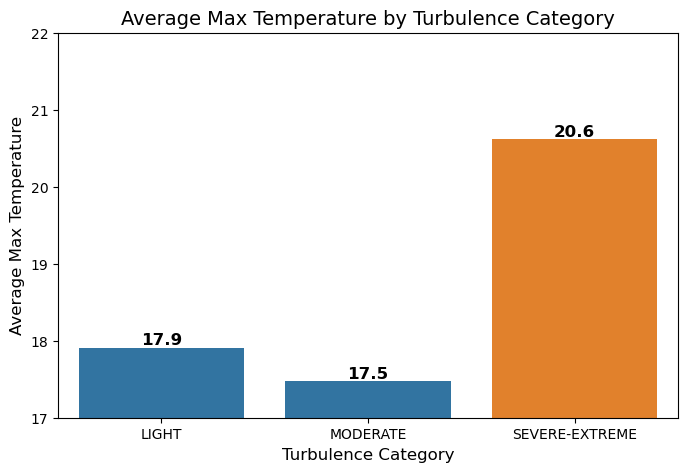

In [33]:
# Filter DataFrame
filtered_df = df[df['TURB_CAT'].isin(['LGT', 'MOD', 'SVR EXT'])]

# Compute average MAX_TEMP per TURB_CAT
weather = filtered_df.groupby('TURB_CAT')['MAX_TEMP'].mean().reset_index()

# Rename categories
rename_dict = {'LGT': 'LIGHT', 'MOD': 'MODERATE', 'SVR EXT': 'SEVERE-EXTREME'}
weather['TURB_CAT'] = weather['TURB_CAT'].replace(rename_dict)

# Define custom order
category_order = ['LIGHT', 'MODERATE', 'SEVERE-EXTREME']
weather['TURB_CAT'] = pd.Categorical(weather['TURB_CAT'], categories=category_order, ordered=True)

# Sort dataframe
weather = weather.sort_values('TURB_CAT')

# Define custom colors
custom_colors = {
    "LIGHT": "#1f77b4",
    "MODERATE": "#1f77b4",
    "SEVERE-EXTREME": "#ff7f0e"
}

# Plot using Seaborn
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='TURB_CAT', y='MAX_TEMP', data=weather, order=category_order, hue = 'TURB_CAT', palette=custom_colors)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Customize plot
plt.xlabel('Turbulence Category', fontsize=12)
plt.ylabel('Average Max Temperature', fontsize=12)
plt.title('Average Max Temperature by Turbulence Category', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(17,22)

# Show plot
plt.show()

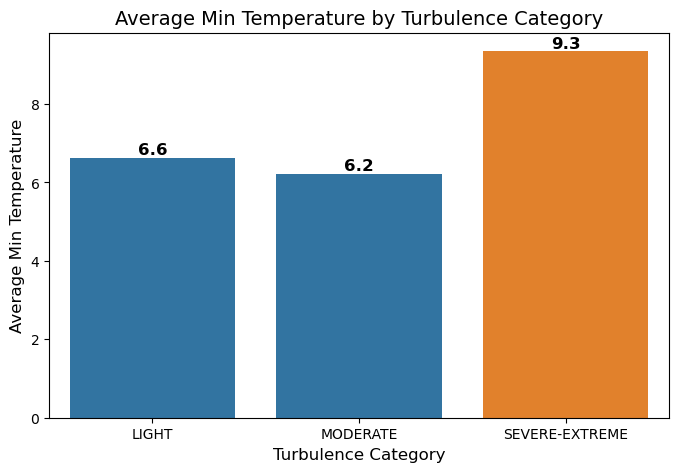

In [34]:
weather = filtered_df.groupby('TURB_CAT')['MIN_TEMP'].mean().reset_index()

# Rename categories
rename_dict = {'LGT': 'LIGHT', 'MOD': 'MODERATE', 'SVR EXT': 'SEVERE-EXTREME'}
weather['TURB_CAT'] = weather['TURB_CAT'].replace(rename_dict)

# Define custom order
category_order = ['LIGHT', 'MODERATE', 'SEVERE-EXTREME']
weather['TURB_CAT'] = pd.Categorical(weather['TURB_CAT'], categories=category_order, ordered=True)

# Sort dataframe
weather = weather.sort_values('TURB_CAT')

# Define custom colors
custom_colors = {
    "LIGHT": "#1f77b4",
    "MODERATE": "#1f77b4",
    "SEVERE-EXTREME": "#ff7f0e"
}

# Plot using Seaborn
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='TURB_CAT', y='MIN_TEMP', data=weather, order=category_order, hue = 'TURB_CAT', palette=custom_colors)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Customize plot
plt.xlabel('Turbulence Category', fontsize=12)
plt.ylabel('Average Min Temperature', fontsize=12)
plt.title('Average Min Temperature by Turbulence Category', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Show plot
plt.show()

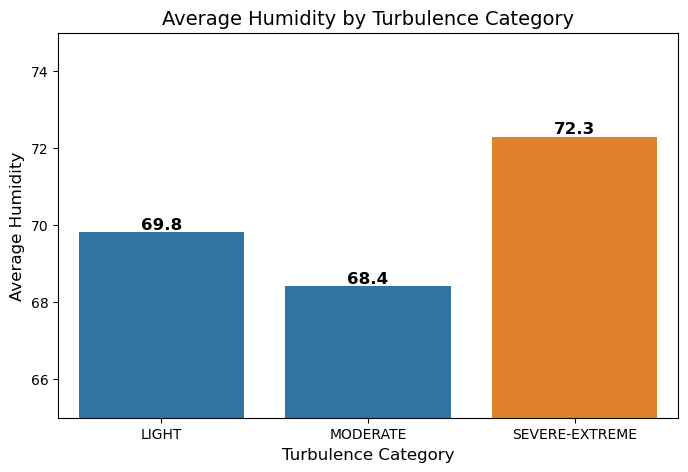

In [35]:
weather = filtered_df.groupby('TURB_CAT')['HUM'].mean().reset_index()

# Rename categories
rename_dict = {'LGT': 'LIGHT', 'MOD': 'MODERATE', 'SVR EXT': 'SEVERE-EXTREME'}
weather['TURB_CAT'] = weather['TURB_CAT'].replace(rename_dict)

# Define custom order
category_order = ['LIGHT', 'MODERATE', 'SEVERE-EXTREME']
weather['TURB_CAT'] = pd.Categorical(weather['TURB_CAT'], categories=category_order, ordered=True)

# Sort dataframe
weather = weather.sort_values('TURB_CAT')

# Define custom colors
custom_colors = {
    "LIGHT": "#1f77b4",
    "MODERATE": "#1f77b4",
    "SEVERE-EXTREME": "#ff7f0e"
}

# Plot using Seaborn
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='TURB_CAT', y='HUM', data=weather, order=category_order, hue = 'TURB_CAT', palette=custom_colors)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Customize plot
plt.xlabel('Turbulence Category', fontsize=12)
plt.ylabel('Average Humidity', fontsize=12)
plt.title('Average Humidity by Turbulence Category', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(65,75)

# Show plot
plt.show()

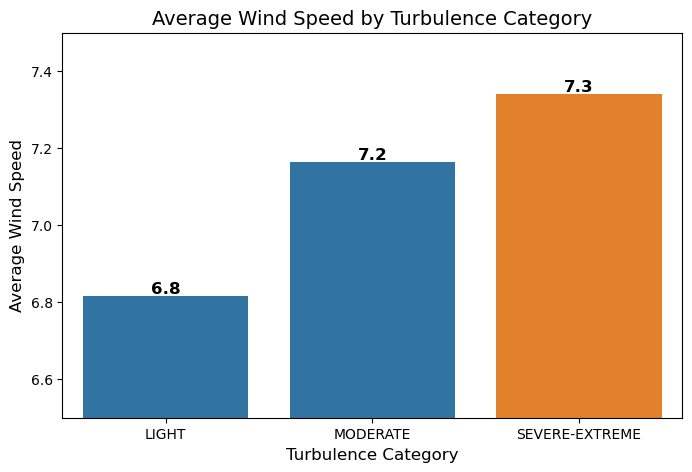

In [36]:
weather = filtered_df.groupby('TURB_CAT')['WIND'].mean().reset_index()

# Rename categories
rename_dict = {'LGT': 'LIGHT', 'MOD': 'MODERATE', 'SVR EXT': 'SEVERE-EXTREME'}
weather['TURB_CAT'] = weather['TURB_CAT'].replace(rename_dict)

# Define custom order
category_order = ['LIGHT', 'MODERATE', 'SEVERE-EXTREME']
weather['TURB_CAT'] = pd.Categorical(weather['TURB_CAT'], categories=category_order, ordered=True)

# Sort dataframe
weather = weather.sort_values('TURB_CAT')

# Define custom colors
custom_colors = {
    "LIGHT": "#1f77b4",
    "MODERATE": "#1f77b4",
    "SEVERE-EXTREME": "#ff7f0e"
}

# Plot using Seaborn
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='TURB_CAT', y='WIND', data=weather, order=category_order, hue = 'TURB_CAT', palette=custom_colors)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Customize plot
plt.xlabel('Turbulence Category', fontsize=12)
plt.ylabel('Average Wind Speed', fontsize=12)
plt.title('Average Wind Speed by Turbulence Category', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(6.5,7.5)

# Show plot
plt.show()

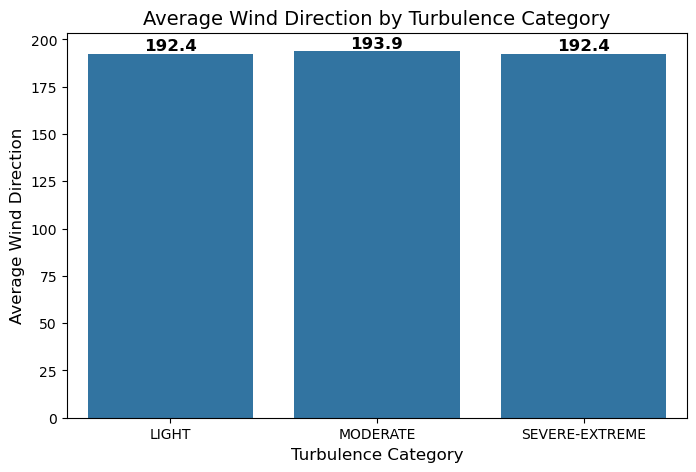

In [37]:
weather = filtered_df.groupby('TURB_CAT')['WIND_DRCT'].mean().reset_index()

# Rename categories
rename_dict = {'LGT': 'LIGHT', 'MOD': 'MODERATE', 'SVR EXT': 'SEVERE-EXTREME'}
weather['TURB_CAT'] = weather['TURB_CAT'].replace(rename_dict)

# Define custom order
category_order = ['LIGHT', 'MODERATE', 'SEVERE-EXTREME']
weather['TURB_CAT'] = pd.Categorical(weather['TURB_CAT'], categories=category_order, ordered=True)

# Sort dataframe
weather = weather.sort_values('TURB_CAT')

# Define custom colors
custom_colors = {
    "LIGHT": "#1f77b4",
    "MODERATE": "#1f77b4",
    "SEVERE-EXTREME": "#1f77b4"
}

# Plot using Seaborn
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='TURB_CAT', y='WIND_DRCT', data=weather, order=category_order, hue = 'TURB_CAT', palette=custom_colors)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Customize plot
plt.xlabel('Turbulence Category', fontsize=12)
plt.ylabel('Average Wind Direction', fontsize=12)
plt.title('Average Wind Direction by Turbulence Category', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Show plot
plt.show()

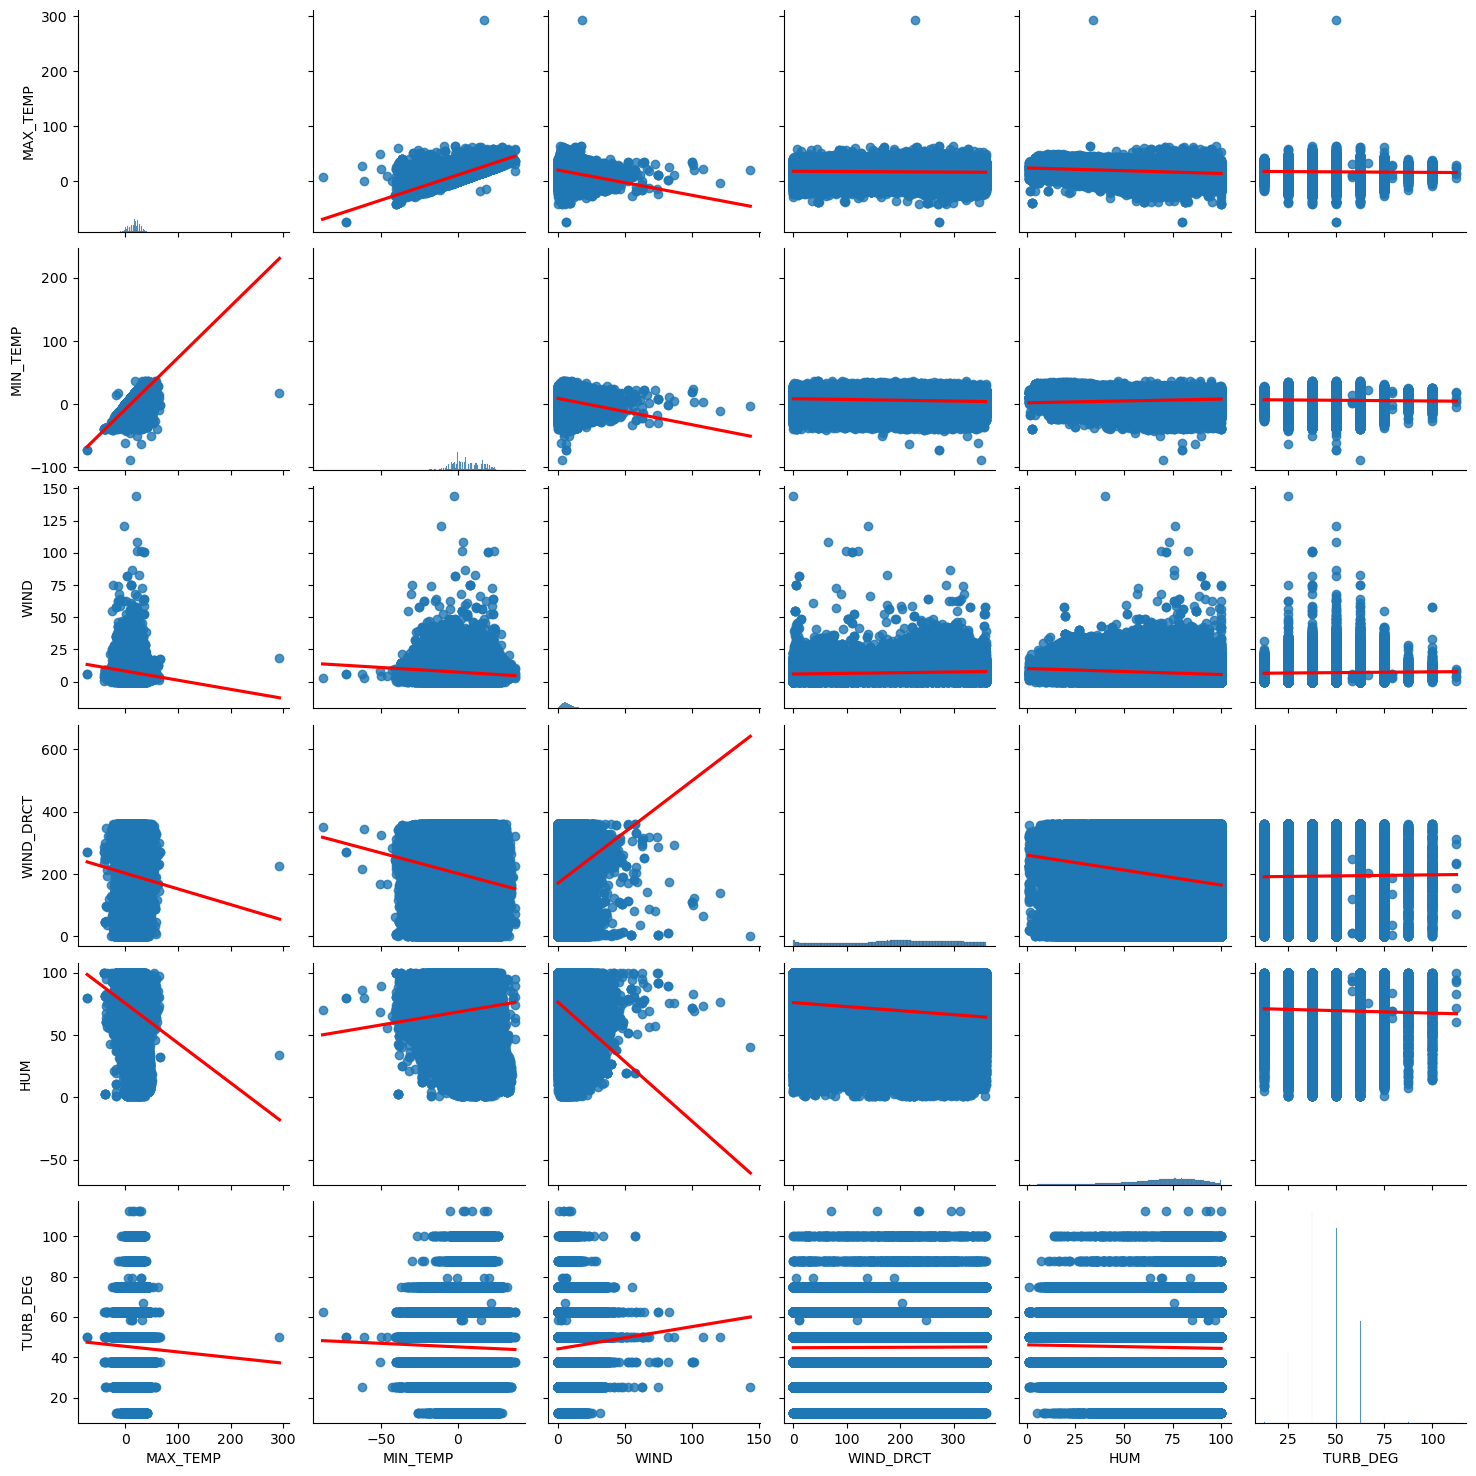

In [120]:
# Select relevant columns
selected_vars = ["MAX_TEMP", "MIN_TEMP", "WIND", "WIND_DRCT", "HUM", "TURB_DEG"]

# Create pairplot with regression trend lines
sns.pairplot(df[selected_vars], kind="reg", plot_kws={'line_kws': {'color': 'red'}})

# Show plot
plt.show()

## Proceed to Part 5.

The key features for modelling have been identified.

Part 5 builds a model on these key features to predict turbulence.

#### Appendix

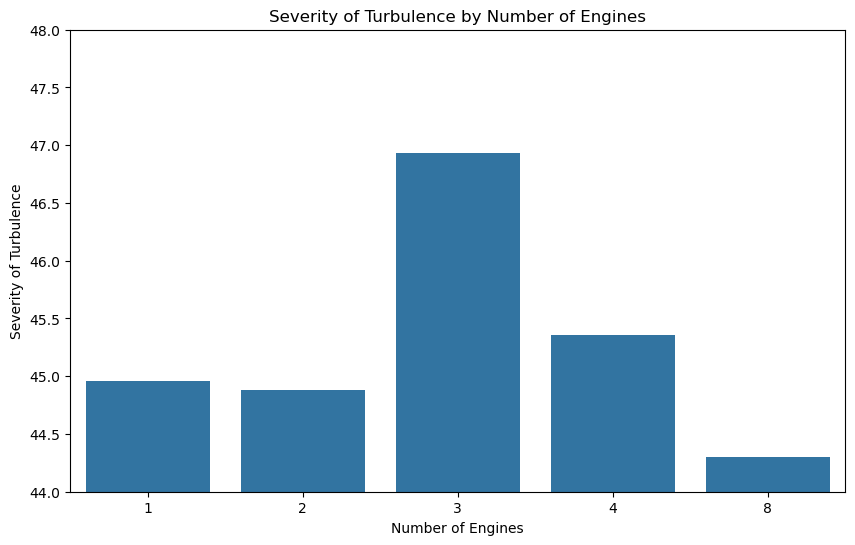

In [113]:
df["ENGINE_COUNT"] = df["ENGINE_COUNT"].astype(int)
engine_turbulence = df.groupby("ENGINE_COUNT")["TURB_DEG"].mean().reset_index()

# Set order for bars
engine_order = ["1", "2", "3", "4","8"]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=engine_turbulence, x="ENGINE_COUNT", y="TURB_DEG",
    order=engine_order, legend=False
)

# Labels and title
plt.xlabel("Number of Engines")
plt.ylabel("Severity of Turbulence")
plt.title("Severity of Turbulence by Number of Engines")
plt.ylim(44, 48)
plt.show()

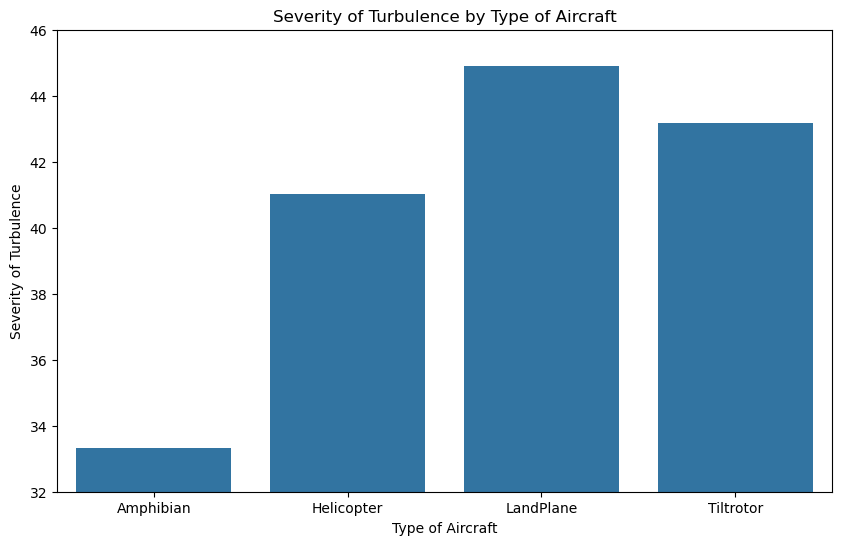

In [129]:
engine_turbulence = df.groupby("DESCRIPTION")["TURB_DEG"].mean().reset_index()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=engine_turbulence, x="DESCRIPTION", y="TURB_DEG",
)

# Labels and title
plt.xlabel("Type of Aircraft")
plt.ylabel("Severity of Turbulence")
plt.title("Severity of Turbulence by Type of Aircraft")
plt.ylim(32, 46)
plt.show()